# Imports

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import plotly.graph_objects as go

# Single $\beta$ Cell Model

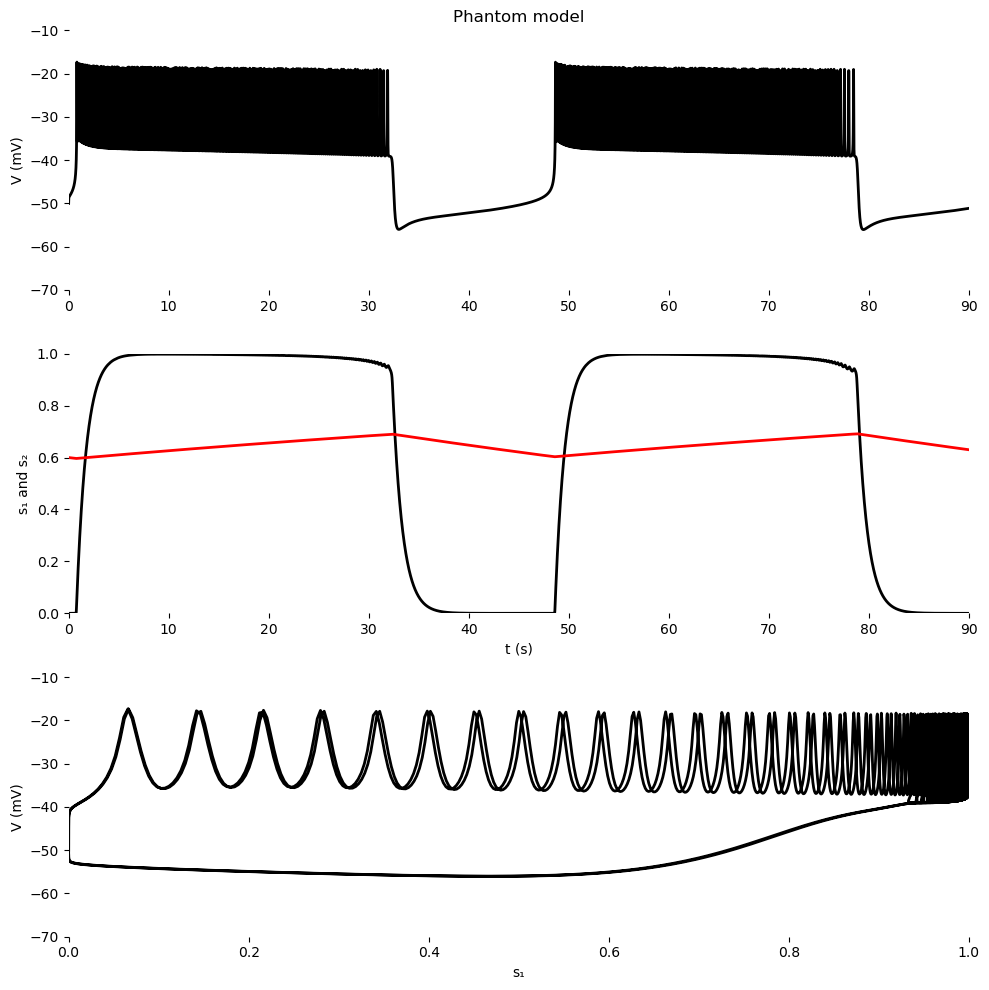

In [2]:
def singleBetaCell(t, x, gs1=5):
    # Parameters most likely to vary
    gs2 = 32
    # autos1 = 1
    # autos2 = 1
    # Other parameters
    taus1 = 1000
    taus2 = 120000
    tnbar = 9.09
    vs1 = -40
    vs2 = -42
    ss1 = 0.5
    ss2 = 0.4
    s1knot = 1
    s2knot = 1
    gl = 25
    vl = -40
    gk = 1300
    vk = -80
    gca = 280
    vca = 100
    lambda_ = 1.1
    cm = 4524
    vm = -22
    sm = 7.5
    vn = -9
    sn = 10
    # Unpack variables
    v, n, s1, s2 = x
    # Gating variables
    minf = 1.0 / (1.0 + np.exp((vm - v) / sm))
    ninf = 1.0 / (1.0 + np.exp((vn - v) / sn))
    taun = tnbar / (1.0 + np.exp((v - vn) / sn))
    s1inf = 1.0 / (1.0 + np.exp((vs1 - v) / ss1))
    s2inf = 1.0 / (1.0 + np.exp((vs2 - v) / ss2))
    # Ionic currents
    ica = gca * minf * (v - vca)
    ik = gk * n * (v - vk)
    il = gl * (v - vl)
    is1 = gs1 * s1 * (v - vk)
    is2 = gs2 * s2 * (v - vk)
    vdot = -(ica + ik + il + is1 + is2) / cm
    ndot = lambda_ * (ninf - n) / taun
    s1dot = (s1inf - s1) / taus1
    s2dot = (s2inf - s2) / taus2
    return [vdot, ndot, s1dot, s2dot]


# Call function
def call_SBC(gs1=5, v0=0.0, tmax=90000):
    tspan = (0, tmax)
    x0 = [-50, 0, 0.0, v0]
    # Solve ODE
    sol = solve_ivp(
        lambda t, x: singleBetaCell(t, x, gs1), tspan, x0, method="RK45", max_step=5.0
    )
    tsec = sol.t / 1000  # convert ms to seconds
    v, n, s1, s2 = sol.y
    # Plotting
    plt.figure(figsize=(10, 10))
    # Top panel
    plt.subplot(3, 1, 1)
    plt.plot(tsec, v, color="black", linewidth=2)
    plt.axis([0, tsec[-1], -70, -10])
    plt.title("Phantom model")
    plt.ylabel("V (mV)")
    plt.box(False)
    # Middle panel
    plt.subplot(3, 1, 2)
    plt.plot(tsec, s1, color="black", linewidth=2, label="s1")
    plt.plot(tsec, s2, color="red", linewidth=2, label="s2")
    plt.axis([0, tsec[-1], 0, 1])
    plt.xlabel("t (s)")
    plt.ylabel("s₁ and s₂")
    plt.box(False)
    # Bottom panel
    plt.subplot(3, 1, 3)
    plt.plot(s1, v, color="black", linewidth=2)
    plt.axis([0, 1, -70, -10])
    plt.xlabel("s₁")
    plt.ylabel("V (mV)")
    plt.box(False)
    plt.tight_layout()
    plt.show()
    # # Write to file
    # output = np.vstack((tsec, v, n, s1, s2)).T
    # np.savetxt("data.dat", output, fmt='%9.5f', header='t(s) v n s1 s2')


def main():
    # Example usage (you can modify gs1, v0, tmax as in Figs 2–4)
    call_SBC(gs1=5, v0=0.6, tmax=90000)


main()

## Single $\beta$ cell class

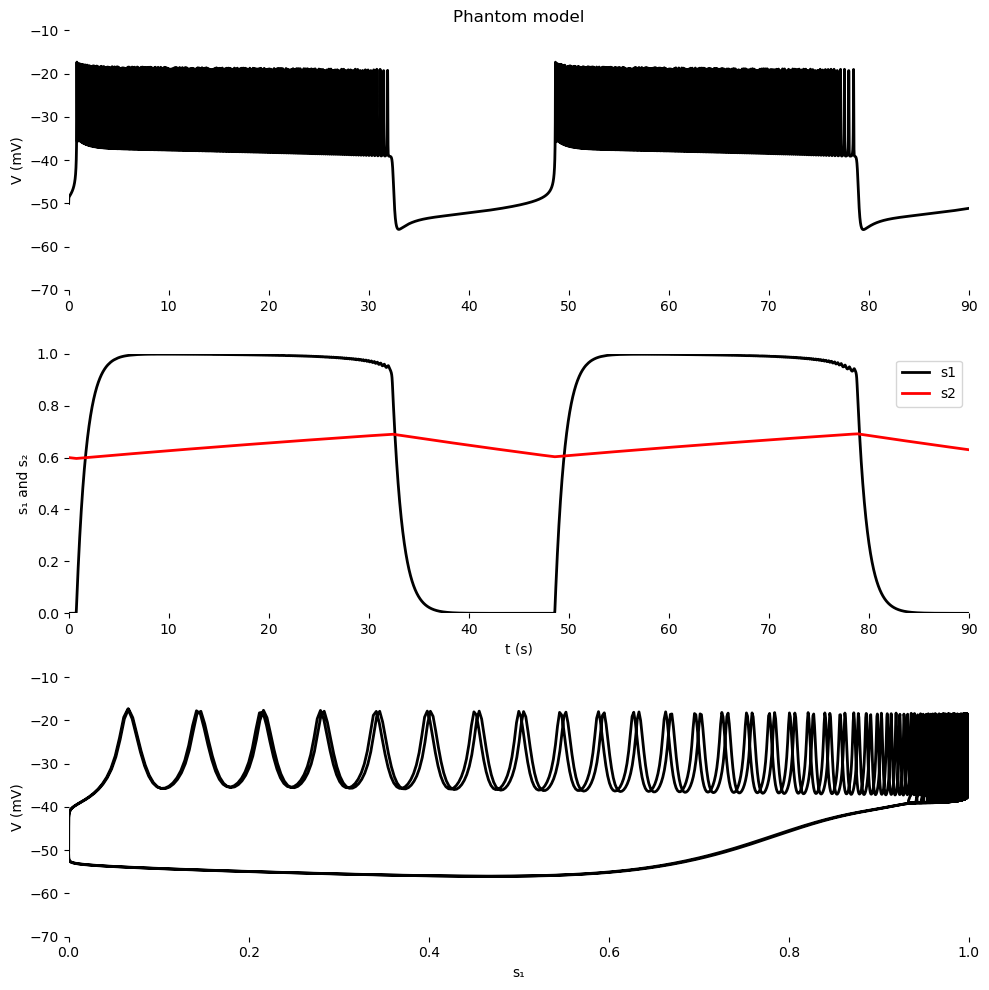

In [3]:
class SingleBetaCell:
    def __init__(
        self,
        gs1=5,
        gs2=32,
        taus1=1000,
        taus2=120000,
        tnbar=9.09,
        vs1=-40,
        vs2=-42,
        ss1=0.5,
        ss2=0.4,
        s1knot=1,
        s2knot=1,
        gl=25,
        vl=-40,
        gk=1300,
        vk=-80,
        gca=280,
        vca=100,
        lambda_=1.1,
        cm=4524,
        vm=-22,
        sm=7.5,
        vn=-9,
        sn=10,
    ):
        # Store all parameters as instance variables
        self.gs1 = gs1
        self.gs2 = gs2
        self.taus1 = taus1
        self.taus2 = taus2
        self.tnbar = tnbar
        self.vs1 = vs1
        self.vs2 = vs2
        self.ss1 = ss1
        self.ss2 = ss2
        self.s1knot = s1knot
        self.s2knot = s2knot
        self.gl = gl
        self.vl = vl
        self.gk = gk
        self.vk = vk
        self.gca = gca
        self.vca = vca
        self.lambda_ = lambda_
        self.cm = cm
        self.vm = vm
        self.sm = sm
        self.vn = vn
        self.sn = sn

    def dynamics(self, t, x, v_neighbors=0, g_total=0):
        """Calculate the dynamics of the beta cell model"""
        # Unpack variables
        v, n, s1, s2 = x

        # Gating variables
        minf = 1.0 / (1.0 + np.exp((self.vm - v) / self.sm))
        ninf = 1.0 / (1.0 + np.exp((self.vn - v) / self.sn))
        taun = self.tnbar / (1.0 + np.exp((v - self.vn) / self.sn))
        s1inf = 1.0 / (1.0 + np.exp((self.vs1 - v) / self.ss1))
        s2inf = 1.0 / (1.0 + np.exp((self.vs2 - v) / self.ss2))

        # Ionic currents
        ica = self.gca * minf * (v - self.vca)
        ik = self.gk * n * (v - self.vk)
        il = self.gl * (v - self.vl)
        is1 = self.gs1 * s1 * (v - self.vk)
        is2 = self.gs2 * s2 * (v - self.vk)

        igj = g_total * (v_neighbors - v) if g_total > 0 else 0

        # Differential equations
        vdot = -(ica + ik + il + is1 + is2 - igj) / self.cm
        ndot = self.lambda_ * (ninf - n) / taun
        s1dot = (s1inf - s1) / self.taus1
        s2dot = (s2inf - s2) / self.taus2

        return np.array([vdot, ndot, s1dot, s2dot])

    def simulate(self, v0=0.0, n0=0.0, s10=0.0, s20=0.6, tmax=90000, max_step=5.0):
        """Simulate the beta cell model"""
        tspan = (0, tmax)
        x0 = [-50, n0, s10, s20]

        # Solve ODE
        sol = solve_ivp(self.dynamics, tspan, x0, method="RK45", max_step=max_step)

        return sol

    def plot_results(self, sol):
        """Plot the simulation results"""
        tsec = sol.t / 1000  # convert ms to seconds
        v, n, s1, s2 = sol.y

        plt.figure(figsize=(10, 10))

        # Top panel
        plt.subplot(3, 1, 1)
        plt.plot(tsec, v, color="black", linewidth=2)
        plt.axis([0, tsec[-1], -70, -10])
        plt.title("Phantom model")
        plt.ylabel("V (mV)")
        plt.box(False)

        # Middle panel
        plt.subplot(3, 1, 2)
        plt.plot(tsec, s1, color="black", linewidth=2, label="s1")
        plt.plot(tsec, s2, color="red", linewidth=2, label="s2")
        plt.axis([0, tsec[-1], 0, 1])
        plt.xlabel("t (s)")
        plt.ylabel("s₁ and s₂")
        plt.legend()
        plt.box(False)

        # Bottom panel
        plt.subplot(3, 1, 3)
        plt.plot(s1, v, color="black", linewidth=2)
        plt.axis([0, 1, -70, -10])
        plt.xlabel("s₁")
        plt.ylabel("V (mV)")
        plt.box(False)

        plt.tight_layout()
        plt.show()

    def run_simulation(self, gs1=5, v0=0.6, tmax=90000):
        """Run a simulation with the given parameters and plot the results"""
        # Update gs1 if needed
        self.gs1 = gs1

        # Run simulation
        sol = self.simulate(s20=v0, tmax=tmax)

        # Plot results
        self.plot_results(sol)

        return sol

    def save_data(self, sol, filename="data.dat"):
        """Save simulation results to a file"""
        tsec = sol.t / 1000  # convert ms to seconds
        v, n, s1, s2 = sol.y
        output = np.vstack((tsec, v, n, s1, s2)).T
        np.savetxt(filename, output, fmt="%9.5f", header="t(s) v n s1 s2")


def main():
    # Create instance of SingleBetaCell with default parameters
    model = SingleBetaCell()

    # Example usage (you can modify gs1, v0, tmax as in Figs 2–4)
    model.run_simulation(gs1=5, v0=0.6, tmax=90000)


main()

# Coupled $\beta$ Cells

All contacting $\beta$-cells were considered to form a functional GJ with  a strength (in pS) picked from a normal distribution of mean 40 pS and standard deviation 1 pS. Each cell may form 1–5 GJ connections with other cells, yielding a total mean GJ conductance of 40–200 pS. This is supported both by experimental and by simulation data from small clusters of dispersed human $\beta$-cells (100–200 pS; Loppini et al. (2015)) and $\beta$-cells recorded in intact mouse islets (<170 pS, Zhang et al. (2008); 50–120 unitary strength, Moreno et al. (2005); 20 pS, Perez-Armendariz et al. (1991)).

In [4]:
class BetaCellNetwork:
    def __init__(
        self, num_cells=10, mean_gj=40, std_gj=1, min_connections=1, max_connections=5
    ):
        """
        Initialize a network of coupled beta cells

        Parameters:
        -----------
        num_cells : int
            Number of beta cells in the network
        mean_gj : float
            Mean gap junction conductance in pS
        std_gj : float
            Standard deviation of gap junction conductance in pS
        min_connections : int
            Minimum number of connections per cell
        max_connections : int
            Maximum number of connections per cell
        """
        self.num_cells = num_cells
        self.mean_gj = mean_gj  # pS
        self.std_gj = std_gj  # pS
        self.min_connections = min_connections
        self.max_connections = max_connections

        # Create individual beta cells with slightly varied parameters
        self.cells = []
        for i in range(num_cells):
            # Add slight variation to parameters
            # gs1 = np.random.normal(5, 0.2)
            # gs2 = np.random.normal(32, 1.0)
            gs1 = np.random.normal(5, 0.05)
            gs2 = np.random.normal(32, 0.2)
            self.cells.append(SingleBetaCell(gs1=gs1, gs2=gs2))

        # Create connectivity matrix (adjacency matrix with weights)
        self.create_network()

    def create_network(self):
        """Create network connectivity with gap junctions"""
        # Initialize adjacency matrix with zeros
        self.adjacency_matrix = np.zeros((self.num_cells, self.num_cells))
        self.gj_matrix = np.zeros((self.num_cells, self.num_cells))

        # Create a graph for visualization
        self.graph = nx.Graph()
        self.graph.add_nodes_from(range(self.num_cells))

        # Assign 3D positions for visualization
        self.positions = {}
        for i in range(self.num_cells):
            # Randomly position cells in 3D space
            self.positions[i] = (np.random.rand(), np.random.rand(), np.random.rand())

        # For each cell, determine connections
        for i in range(self.num_cells):
            # Determine number of connections for this cell
            num_connections = np.random.randint(
                self.min_connections, self.max_connections + 1
            )

            # Find cells that are not yet connected to cell i
            possible_connections = [
                j
                for j in range(self.num_cells)
                if j != i and self.adjacency_matrix[i, j] == 0
            ]

            # If we have fewer possible connections than needed, use all available
            num_connections = min(num_connections, len(possible_connections))

            # Choose random cells to connect with
            if possible_connections:
                # Calculate distances between cell i and all other cells
                distances = {}
                for j in possible_connections:
                    pos_i = self.positions[i]
                    pos_j = self.positions[j]
                    dist = np.sqrt(
                        (pos_i[0] - pos_j[0]) ** 2
                        + (pos_i[1] - pos_j[1]) ** 2
                        + (pos_i[2] - pos_j[2]) ** 2
                    )
                    distances[j] = dist

                # Sort by distance and prefer closer cells (with some randomness)
                sorted_cells = sorted(distances.items(), key=lambda x: x[1])
                preferred_cells = [
                    cell for cell, _ in sorted_cells[: num_connections * 2]
                ]

                if len(preferred_cells) > num_connections:
                    connected_cells = np.random.choice(
                        preferred_cells, num_connections, replace=False
                    )
                else:
                    connected_cells = preferred_cells

                # Create connections with random gap junction conductances
                for j in connected_cells:
                    # Generate a random conductance from normal distribution
                    conductance = np.random.normal(self.mean_gj, self.std_gj)
                    conductance = max(1, conductance)  # Ensure positive conductance

                    # Set the adjacency matrix (symmetric)
                    self.adjacency_matrix[i, j] = conductance
                    self.adjacency_matrix[j, i] = conductance

                    gj_value = max(0, np.random.normal(self.mean_gj, self.std_gj))
                    self.adjacency_matrix[i, j] = self.adjacency_matrix[j, i] = 1
                    self.gj_matrix[i, j] = self.gj_matrix[j, i] = gj_value

                    # make the size of the edge proportional to gj_value
                    # self.graph.edges[i, j]['weight'] = gj_value

                    # Add edge to graph
                    self.graph.add_edge(i, j, weight=conductance)

    def network_dynamics(self, t, X):
        dXdt = np.zeros_like(X)
        for i, cell in enumerate(self.cells):
            idx = 4 * i
            vi = X[idx]
            vi_neighbors = 0
            g_total = 0
            for j in range(self.num_cells):
                if i != j and self.adjacency_matrix[i, j]:
                    vj = X[4 * j]
                    gj = self.gj_matrix[i, j]
                    vi_neighbors += gj * vj
                    g_total += gj
            v_neighbors = vi_neighbors / g_total if g_total > 0 else vi
            dXdt[idx : idx + 4] = cell.dynamics(
                t, X[idx : idx + 4], v_neighbors, g_total
            )
        return dXdt

    def dynamics(self, t, x):
        """
        Coupled dynamics of all cells in the network

        Parameters:
        -----------
        t : float
            Current time
        x : array
            State variables for all cells: [v1, n1, s11, s21, v2, n2, s12, s22, ...]

        Returns:
        --------
        dxdt : array
            Derivatives of state variables
        """
        # Reshape to get state for each cell
        x_reshaped = x.reshape(self.num_cells, 4)

        # Initialize the derivative array
        dxdt = np.zeros_like(x_reshaped)

        # Calculate intrinsic dynamics for each cell
        for i in range(self.num_cells):
            dxdt[i] = self.cells[i].dynamics(t, x_reshaped[i])

        # Add gap junction currents to voltage derivatives
        for i in range(self.num_cells):
            v_i = x_reshaped[i, 0]  # Voltage of cell i

            # Sum up gap junction currents
            gj_current = 0
            for j in range(self.num_cells):
                if self.adjacency_matrix[i, j] > 0:
                    v_j = x_reshaped[j, 0]  # Voltage of cell j
                    gj = self.adjacency_matrix[i, j] # * 1e-12  # Convert pS to S # TODO
                    gj_current += gj * (v_j - v_i)

            # Add gap junction current to voltage derivative (I = g*dV)
            dxdt[i, 0] += gj_current / self.cells[i].cm

        # Return flattened array
        return dxdt.flatten()

    def simulate(self, tmax=90000, max_step=10.0):
        """
        Simulate the network of coupled beta cells

        Parameters:
        -----------
        tmax : float
            Maximum simulation time in ms
        max_step : float
            Maximum step size for solver

        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """

        x0 = np.array([-50, 0, 0, 0.6] * self.num_cells)
        tspan = (0, tmax)

        # Solve the system
        sol = solve_ivp(self.network_dynamics, tspan, x0, method="RK45", max_step=max_step)

        return sol

    def plot_network(self):
        """Visualize the network connectivity"""
        plt.figure(figsize=(10, 8))
        ax = plt.subplot(111, projection="3d")

        # Extract 3D positions
        pos = self.positions
        xs = [pos[i][0] for i in range(self.num_cells)]
        ys = [pos[i][1] for i in range(self.num_cells)]
        zs = [pos[i][2] for i in range(self.num_cells)]

        # Plot nodes
        ax.scatter(xs, ys, zs, s=100, c="blue", alpha=0.7)

        # Plot edges
        for i, j in self.graph.edges():
            weight = self.adjacency_matrix[i, j]
            x = [pos[i][0], pos[j][0]]
            y = [pos[i][1], pos[j][1]]
            z = [pos[i][2], pos[j][2]]
            # Line width proportional to weight
            lw = 0.5 + 2.0 * weight / self.mean_gj
            ax.plot(x, y, z, "gray", alpha=0.5, linewidth=lw)

        # Add node labels
        for i in range(self.num_cells):
            ax.text(pos[i][0], pos[i][1], pos[i][2], str(i), fontsize=12)

        ax.set_title(f"Beta Cell Network (n={self.num_cells})")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        plt.tight_layout()
        plt.show()

    def plot_results(self, sol):
        """
        Plot simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        """
        # Convert time from ms to seconds
        tsec = sol.t / 1000

        # Create a figure with multiple subplots
        fig = plt.figure(figsize=(15, 12))

        # Plot voltages
        ax1 = fig.add_subplot(3, 1, 1)
        for i in range(self.num_cells):
            v = sol.y[i * 4]
            ax1.plot(
                tsec, v, linewidth=1, alpha=0.7, label=f"Cell {i}" if i < 5 else ""
            )

        ax1.set_xlim(0, tsec[-1])
        ax1.set_ylim(-70, -10)
        ax1.set_ylabel("V (mV)")
        ax1.set_title(f"Membrane Potentials of {self.num_cells} Coupled Beta Cells")
        if self.num_cells <= 5:
            ax1.legend(loc="upper right")
        else:
            ax1.legend(loc="upper right", ncol=2)

        # Plot s1 variables
        ax2 = fig.add_subplot(3, 1, 2)
        for i in range(self.num_cells):
            s1 = sol.y[i * 4 + 2]
            ax2.plot(tsec, s1, linewidth=1, alpha=0.7)

        ax2.set_xlim(0, tsec[-1])
        ax2.set_ylim(0, 1)
        ax2.set_xlabel("t (s)")
        ax2.set_ylabel("s₁")
        ax2.set_title("Slow Variable s₁")

        # Plot s2 variables
        ax3 = fig.add_subplot(3, 1, 3)
        for i in range(self.num_cells):
            s2 = sol.y[i * 4 + 3]
            ax3.plot(tsec, s2, linewidth=1, alpha=0.7)

        ax3.set_xlim(0, tsec[-1])
        ax3.set_ylim(0, 1)
        ax3.set_xlabel("t (s)")
        ax3.set_ylabel("s₂")
        ax3.set_title("Slow Variable s₂")

        plt.tight_layout()
        plt.show()

        # Plot a phase space of s1 vs V for the first few cells
        plt.figure(figsize=(12, 8))
        for i in range(min(5, self.num_cells)):
            v = sol.y[i * 4]
            s1 = sol.y[i * 4 + 2]
            plt.plot(s1, v, linewidth=1, alpha=0.7, label=f"Cell {i}")

        plt.xlim(0, 1)
        plt.ylim(-70, -10)
        plt.xlabel("s₁")
        plt.ylabel("V (mV)")
        plt.title("Phase Space (s₁ vs V)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

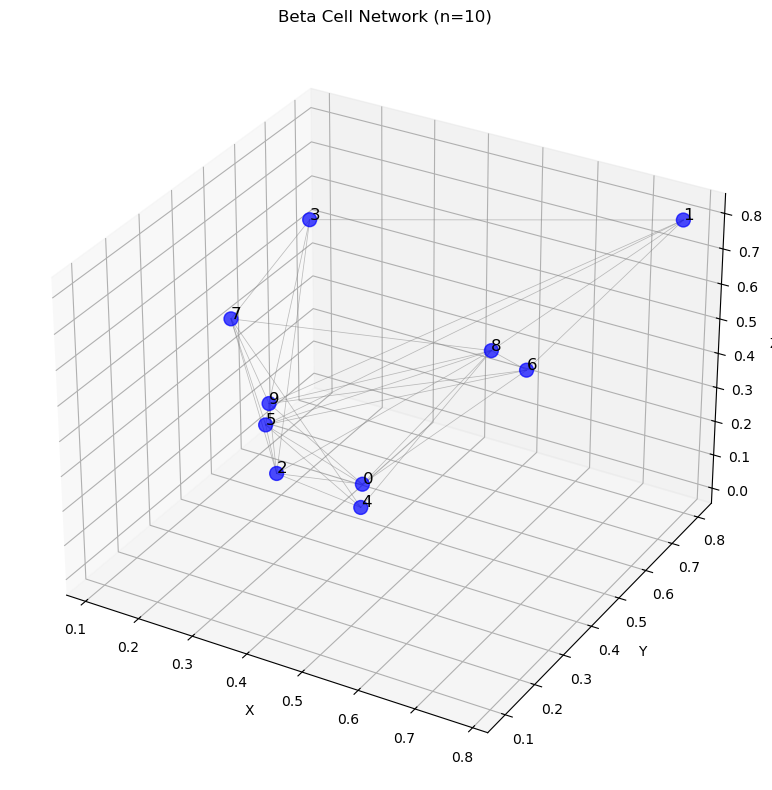

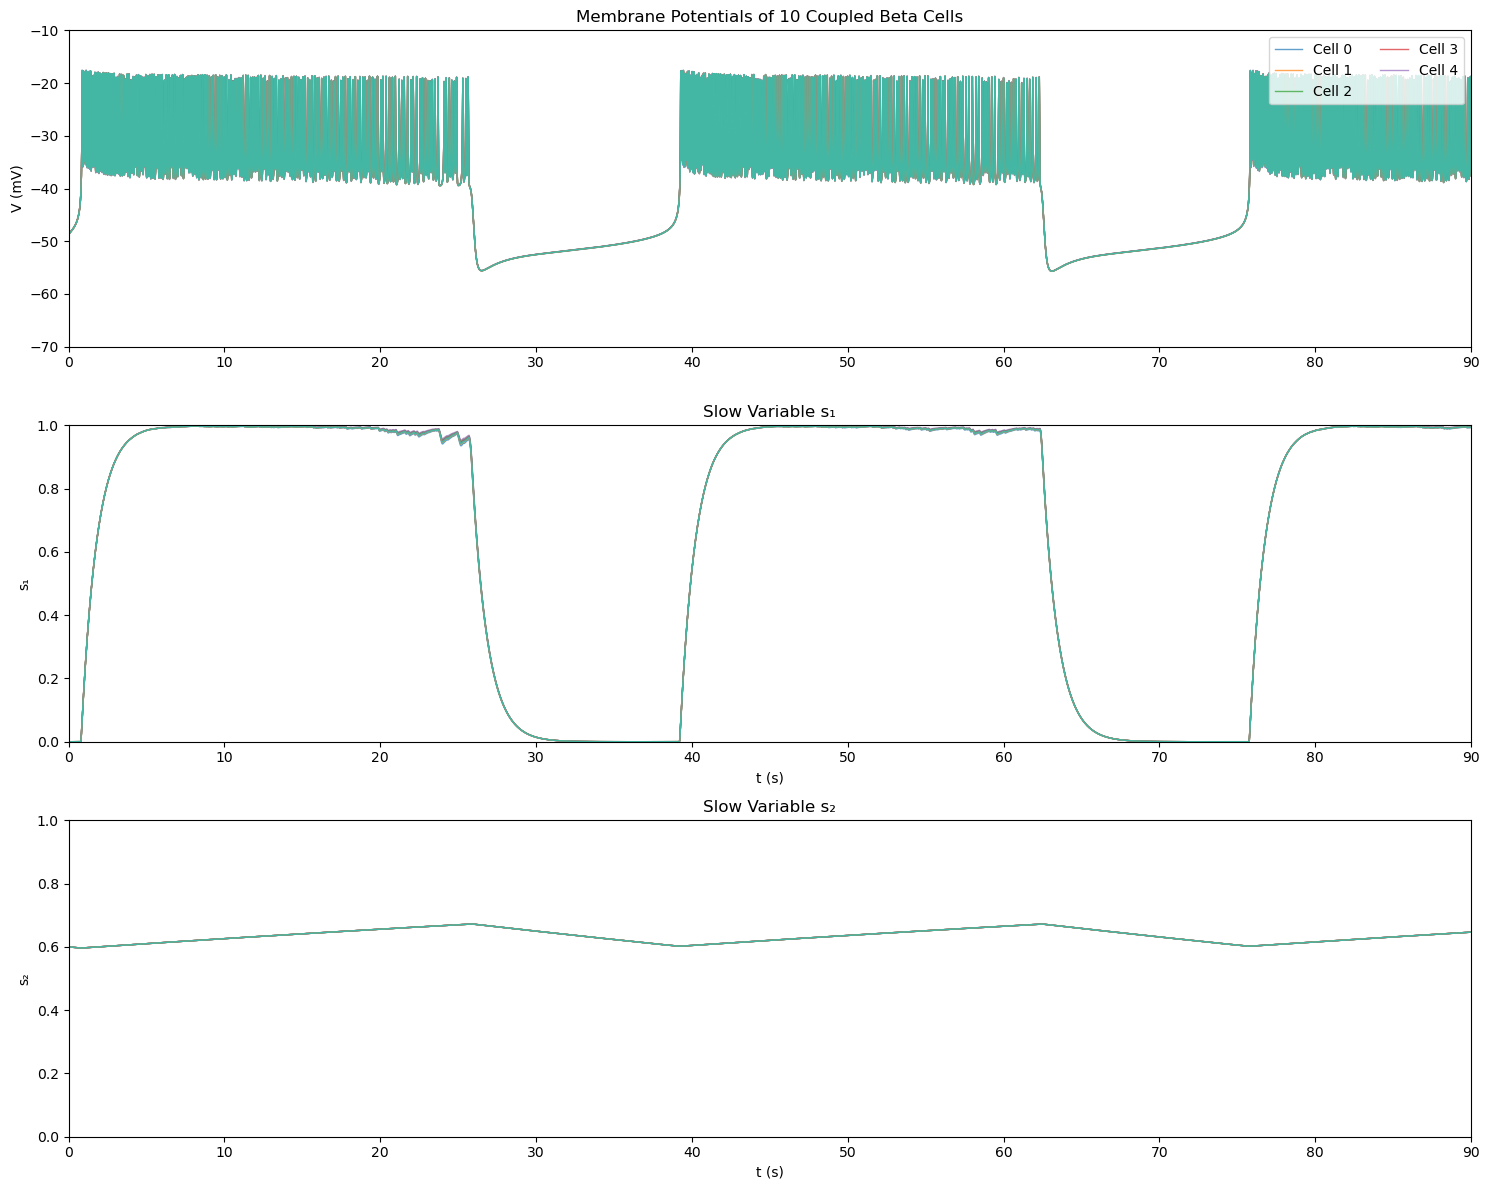

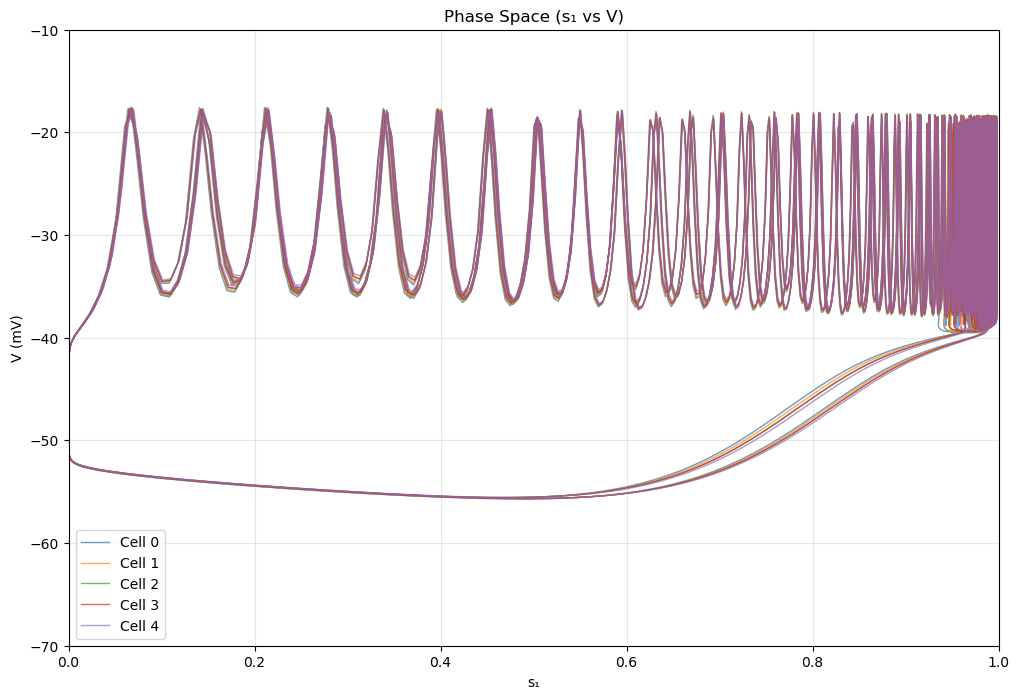

In [5]:
def main():
    # Create a network of 10 beta cells w/ gap junctions
    network = BetaCellNetwork(
        num_cells=10, mean_gj=40, std_gj=8, min_connections=1, max_connections=5
    )

    # No gap junctions, de-synchronized
    # network = BetaCellNetwork(
    #    num_cells=10, mean_gj=0, std_gj=0, min_connections=1, max_connections=5
    # )

    # Visualize the network
    network.plot_network()

    # Simulate network dynamics
    sol = network.simulate(tmax=90000)

    # Plot results
    network.plot_results(sol)


main()

# Single $\delta$ cell

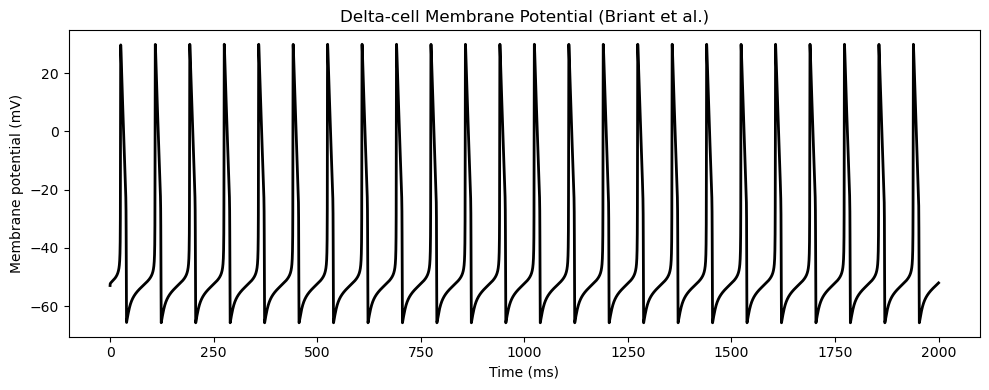

In [6]:
# Delta-cell Model (Converted from Briant et al., Figure 7)

# Parameters
params = {
    "gkatp": 0.01,
    "gna": 11,
    "gka": 1.2,
    "gkdr": 4.5,
    "vna": 60,
    "vk": -75,
    "vca": 65,
    "vl": -40,
    "cm": 4e-3,
    "gcal": 0.65,
    "gcat": 0.05,
    "gcan": 0.3,
    "gl": 0.1,
    "vcalm": -30,
    "scalm": 10,
    "vcalh": -33,
    "scalh": -5,
    "tcalh1": 60,
    "tcalh2": 51,
    "vcatm": -49,
    "scatm": 4,
    "vcath": -52,
    "scath": -5,
    "tcatm1": 15,
    "tcatm2": 0,
    "tcath1": 20,
    "tcath2": 5,
    "vcanm": -5,
    "scanm": 10,
    "vcanh": -33,
    "scanh": -5,
    "tcanh1": 2,
    "tcanh2": 2,
    "vnam": -30,
    "vnah": -52,
    "snam": 4,
    "snah": -8,
    "tnah1": 120,
    "tnah2": 0.5,
    "vkam": -45,
    "skam": 10,
    "vkah": -68,
    "skah": -10,
    "taukam": 0.1,
    "tkah1": 60,
    "tkah2": 5,
    "taukm": 1,
    "vkdrm": -25,
    "skdrm": 23,
    "V2m": -28.8749674,
    "sm": -5.45289598,
    "V2h": -45.388663,
    "sh": 4.99005762,
    "a1taum": 0.0001072,
    "b1taum": 12,
    "c1taum": 40,
    "a2taum": 0.000152,
    "b2taum": -20,
    "c2taum": 22.69,
    "a1tauh": 0.0001636,
    "b1tauh": -15,
    "c1tauh": 8.6856,
    "a2tauh": 0.0001857,
    "b2tauh": 5,
    "c2tauh": 35.35,
}

# Initial conditions
init = {
    "v": -52.91,
    "mcal": 0.092,
    "hcal": 0.857,
    "mcat": 0.27,
    "hcat": 0.534,
    "mcan": 0.008,
    "hcan": 0.857,
    "mna": 0.003,
    "hna": 0.339,
    "mka": 0.312,
    "hka": 0.182,
    "mkdr": 0.237,
}


# Model equations
def delta_cell_model(t, y):
    v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr = y
    p = params

    # Steady states and time constants
    mcalinf = 1 / (1 + np.exp(-(v - p["vcalm"]) / p["scalm"]))
    hcalinf = 1 / (1 + np.exp(-(v - p["vcalh"]) / p["scalh"]))
    taucalm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
    taucalh = (p["tcalh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcalh2"]

    mcatinf = 1 / (1 + np.exp(-(v - p["vcatm"]) / p["scatm"]))
    hcatinf = 1 / (1 + np.exp(-(v - p["vcath"]) / p["scath"]))
    taucatm = (p["tcatm1"] / (np.exp(-(v + 50) / 12) + np.exp((v + 50) / 12))) + p[
        "tcatm2"
    ]
    taucath = (p["tcath1"] / (np.exp(-(v + 50) / 15) + np.exp((v + 50) / 15))) + p[
        "tcath2"
    ]

    mcaninf = 1 / (1 + np.exp(-(v - p["vcanm"]) / p["scanm"]))
    hcaninf = 1 / (1 + np.exp(-(v - p["vcanh"]) / p["scanh"]))
    taucanm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
    taucanh = (p["tcanh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcanh2"]

    mnainf = 1 / (1 + np.exp((v - p["V2m"]) / p["sm"]))
    hnainf = 1 / (1 + np.exp((v - p["V2h"]) / p["sh"]))
    taunam = 1e3 * (
        p["a1taum"] * np.exp(-(((v - p["b1taum"]) / p["c1taum"]) ** 2))
        + p["a2taum"] * np.exp(-(((v - p["b2taum"]) / p["c2taum"]) ** 2))
    )
    taunah = 1e3 * (
        p["a1tauh"] * np.exp(-(((v - p["b1tauh"]) / p["c1tauh"]) ** 2))
        + p["a2tauh"] * np.exp(-(((v - p["b2tauh"]) / p["c2tauh"]) ** 2))
    )

    mkainf = 1 / (1 + np.exp(-(v - p["vkam"]) / p["skam"]))
    hkainf = 1 / (1 + np.exp(-(v - p["vkah"]) / p["skah"]))
    taukah = (p["tkah1"] / (np.exp(-(v - 5) / 20) + np.exp((v - 5) / 20))) + p["tkah2"]

    mkdrinf = 1 / (1 + np.exp(-(v - p["vkdrm"]) / p["skdrm"]))
    taukdrm = p["taukm"] * (
        (1.5 / (np.exp(-(v + 10) / 25) + np.exp((v + 10) / 25))) + 15
    )

    Ical = p["gcal"] * mcal**2 * hcal * (v - p["vca"])
    Icat = p["gcat"] * mcat**3 * hcat * (v - p["vca"])
    Ican = p["gcan"] * mcan * hcan * (v - p["vca"])
    Ina = p["gna"] * mna**5 * hna * (v - p["vna"])
    Ika = p["gka"] * mka * hka * (v - p["vk"])
    Ikdr = p["gkdr"] * mkdr**4 * (v - p["vk"])
    Ikatp = p["gkatp"] * (v - p["vk"])
    Il = p["gl"] * (v - p["vl"])

    dv = -(Ical + Icat + Ican + Ina + Ikdr + Ikatp + Ika + Il) / p["cm"]
    dmcal = (mcalinf - mcal) / (1 * taucalm)
    dhcal = (hcalinf - hcal) / (1 * taucalh)
    dmcat = (mcatinf - mcat) / (1 * taucatm)
    dhcat = (hcatinf - hcat) / (1 * taucath)
    dmcan = (mcaninf - mcan) / (1 * taucanm)
    dhcan = (hcaninf - hcan) / (1 * taucanh)
    dmna = (mnainf - mna) / taunam
    dhna = (hnainf - hna) / taunah
    dmka = (mkainf - mka) / p["taukam"]
    dhka = (hkainf - hka) / taukah
    dmkdr = (mkdrinf - mkdr) / taukdrm

    return [dv, dmcal, dhcal, dmcat, dhcat, dmcan, dhcan, dmna, dhna, dmka, dhka, dmkdr]


# Initial conditions vector
y0 = [
    init[k]
    for k in [
        "v",
        "mcal",
        "hcal",
        "mcat",
        "hcat",
        "mcan",
        "hcan",
        "mna",
        "hna",
        "mka",
        "hka",
        "mkdr",
    ]
]

# Solve ODE
t_span = (0, 2000)
sol = solve_ivp(
    delta_cell_model,
    t_span,
    y0,
    method="LSODA",
    t_eval=np.linspace(*t_span, 20000),
    rtol=1e-10,
    atol=1e-10,
)

plt.figure(figsize=(10, 4))
plt.plot(sol.t, sol.y[0], color="black", linewidth=2, label="V (membrane potential)")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Delta-cell Membrane Potential (Briant et al.)")
plt.grid(False)
plt.tight_layout()
plt.show()

# Single $\delta$ cell class

In [7]:
class SingleDeltaCell:
    def __init__(self, **kwargs):
        """
        Initialize a single delta cell model based on Briant et al.

        Parameters:
        -----------
        **kwargs: Parameter overrides for the delta cell model
        """
        # Default parameters
        self.params = {
            "gkatp": 0.01,
            "gna": 11,
            "gka": 1.2,
            "gkdr": 4.5,
            "vna": 60,
            "vk": -75,
            "vca": 65,
            "vl": -40,
            "cm": 4e-3,
            "gcal": 0.65,
            "gcat": 0.05,
            "gcan": 0.3,
            "gl": 0.1,
            "vcalm": -30,
            "scalm": 10,
            "vcalh": -33,
            "scalh": -5,
            "tcalh1": 60,
            "tcalh2": 51,
            "vcatm": -49,
            "scatm": 4,
            "vcath": -52,
            "scath": -5,
            "tcatm1": 15,
            "tcatm2": 0,
            "tcath1": 20,
            "tcath2": 5,
            "vcanm": -5,
            "scanm": 10,
            "vcanh": -33,
            "scanh": -5,
            "tcanh1": 2,
            "tcanh2": 2,
            "vnam": -30,
            "vnah": -52,
            "snam": 4,
            "snah": -8,
            "tnah1": 120,
            "tnah2": 0.5,
            "vkam": -45,
            "skam": 10,
            "vkah": -68,
            "skah": -10,
            "taukam": 0.1,
            "tkah1": 60,
            "tkah2": 5,
            "taukm": 1,
            "vkdrm": -25,
            "skdrm": 23,
            "V2m": -28.8749674,
            "sm": -5.45289598,
            "V2h": -45.388663,
            "sh": 4.99005762,
            "a1taum": 0.0001072,
            "b1taum": 12,
            "c1taum": 40,
            "a2taum": 0.000152,
            "b2taum": -20,
            "c2taum": 22.69,
            "a1tauh": 0.0001636,
            "b1tauh": -15,
            "c1tauh": 8.6856,
            "a2tauh": 0.0001857,
            "b2tauh": 5,
            "c2tauh": 35.35,
        }

        # Update parameters with any provided values
        self.params.update(kwargs)

        # Default initial conditions
        self.init = {
            "v": -52.91,
            "mcal": 0.092,
            "hcal": 0.857,
            "mcat": 0.27,
            "hcat": 0.534,
            "mcan": 0.008,
            "hcan": 0.857,
            "mna": 0.003,
            "hna": 0.339,
            "mka": 0.312,
            "hka": 0.182,
            "mkdr": 0.237,
        }

    def dynamics(self, t, y, v_neighbors=None, g_total=0):
        """
        Calculate the dynamics of the delta cell model

        Parameters:
        -----------
        t : float
            Current time
        y : array-like
            State variables: [v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr]
        v_neighbors : float or None
            Average voltage of neighboring cells
        g_total : float
            Total gap junction conductance to neighbors

        Returns:
        --------
        dydt : array
            Derivatives of state variables
        """
        v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr = y
        p = self.params

        # Steady states and time constants
        mcalinf = 1 / (1 + np.exp(-(v - p["vcalm"]) / p["scalm"]))
        hcalinf = 1 / (1 + np.exp(-(v - p["vcalh"]) / p["scalh"]))
        taucalm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucalh = (p["tcalh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcalh2"]

        mcatinf = 1 / (1 + np.exp(-(v - p["vcatm"]) / p["scatm"]))
        hcatinf = 1 / (1 + np.exp(-(v - p["vcath"]) / p["scath"]))
        taucatm = (p["tcatm1"] / (np.exp(-(v + 50) / 12) + np.exp((v + 50) / 12))) + p[
            "tcatm2"
        ]
        taucath = (p["tcath1"] / (np.exp(-(v + 50) / 15) + np.exp((v + 50) / 15))) + p[
            "tcath2"
        ]

        mcaninf = 1 / (1 + np.exp(-(v - p["vcanm"]) / p["scanm"]))
        hcaninf = 1 / (1 + np.exp(-(v - p["vcanh"]) / p["scanh"]))
        taucanm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucanh = (p["tcanh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcanh2"]

        mnainf = 1 / (1 + np.exp((v - p["V2m"]) / p["sm"]))
        hnainf = 1 / (1 + np.exp((v - p["V2h"]) / p["sh"]))
        taunam = 1e3 * (
            p["a1taum"] * np.exp(-(((v - p["b1taum"]) / p["c1taum"]) ** 2))
            + p["a2taum"] * np.exp(-(((v - p["b2taum"]) / p["c2taum"]) ** 2))
        )
        taunah = 1e3 * (
            p["a1tauh"] * np.exp(-(((v - p["b1tauh"]) / p["c1tauh"]) ** 2))
            + p["a2tauh"] * np.exp(-(((v - p["b2tauh"]) / p["c2tauh"]) ** 2))
        )

        mkainf = 1 / (1 + np.exp(-(v - p["vkam"]) / p["skam"]))
        hkainf = 1 / (1 + np.exp(-(v - p["vkah"]) / p["skah"]))
        taukah = (p["tkah1"] / (np.exp(-(v - 5) / 20) + np.exp((v - 5) / 20))) + p[
            "tkah2"
        ]

        mkdrinf = 1 / (1 + np.exp(-(v - p["vkdrm"]) / p["skdrm"]))
        taukdrm = p["taukm"] * (
            (1.5 / (np.exp(-(v + 10) / 25) + np.exp((v + 10) / 25))) + 15
        )

        # Ionic currents
        Ical = p["gcal"] * mcal**2 * hcal * (v - p["vca"])
        Icat = p["gcat"] * mcat**3 * hcat * (v - p["vca"])
        Ican = p["gcan"] * mcan * hcan * (v - p["vca"])
        Ina = p["gna"] * mna**5 * hna * (v - p["vna"])
        Ika = p["gka"] * mka * hka * (v - p["vk"])
        Ikdr = p["gkdr"] * mkdr**4 * (v - p["vk"])
        Ikatp = p["gkatp"] * (v - p["vk"])
        Il = p["gl"] * (v - p["vl"])

        # Gap junction current
        Igj = g_total * (v_neighbors - v) if v_neighbors is not None else 0

        # Differential equations
        dydt = np.zeros(12)
        dydt[0] = (
            -(Ical + Icat + Ican + Ina + Ikdr + Ikatp + Ika + Il - Igj) / p["cm"]
        )  # dv
        dydt[1] = (mcalinf - mcal) / (1 * taucalm)  # dmcal
        dydt[2] = (hcalinf - hcal) / (1 * taucalh)  # dhcal
        dydt[3] = (mcatinf - mcat) / (1 * taucatm)  # dmcat
        dydt[4] = (hcatinf - hcat) / (1 * taucath)  # dhcat
        dydt[5] = (mcaninf - mcan) / (1 * taucanm)  # dmcan
        dydt[6] = (hcaninf - hcan) / (1 * taucanh)  # dhcan
        dydt[7] = (mnainf - mna) / taunam  # dmna
        dydt[8] = (hnainf - hna) / taunah  # dhna
        dydt[9] = (mkainf - mka) / p["taukam"]  # dmka
        dydt[10] = (hkainf - hka) / taukah  # dhka
        dydt[11] = (mkdrinf - mkdr) / taukdrm  # dmkdr

        return dydt

    def simulate(self, tmax=2000, max_step=5.0):
        """
        Simulate the delta cell model

        Parameters:
        -----------
        tmax : float
            Maximum simulation time in ms
        max_step : float
            Maximum step size for the solver

        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """
        # Initial conditions vector
        y0 = [
            self.init[k]
            for k in [
                "v",
                "mcal",
                "hcal",
                "mcat",
                "hcat",
                "mcan",
                "hcan",
                "mna",
                "hna",
                "mka",
                "hka",
                "mkdr",
            ]
        ]

        tspan = (0, tmax)

        # Solve ODE
        sol = solve_ivp(
            self.dynamics,
            tspan,
            y0,
            method="LSODA",
            max_step=max_step,
            rtol=1e-8,
            atol=1e-8,
        )

        return sol

    def plot_results(self, sol, figure_size=(12, 8)):
        """
        Plot the simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        """
        plt.figure(figsize=figure_size)

        # Plot voltage
        plt.plot(sol.t, sol.y[0], color="black", linewidth=2)
        plt.ylabel("V (mV)")
        plt.title("Delta Cell Model")

        plt.tight_layout()
        plt.show()

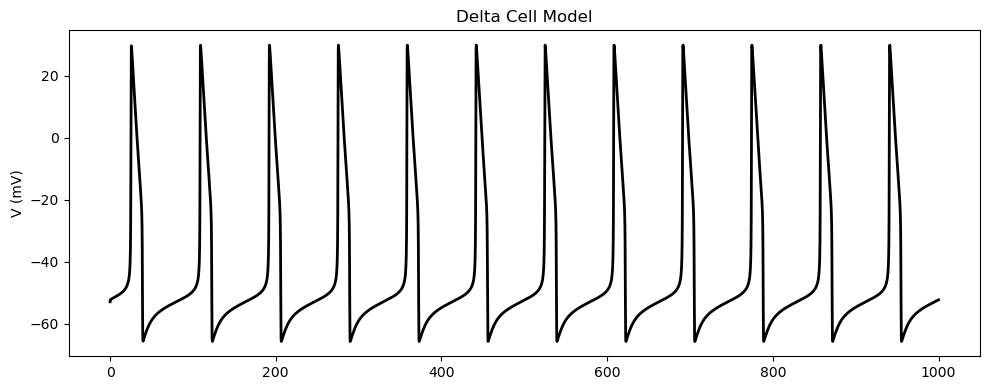

In [8]:
def main():
    cell = SingleDeltaCell()
    sol = cell.simulate(tmax=1000)
    _ = cell.plot_results(sol, figure_size=(10, 4))


main()

# Coupled $\delta$ cell model

In [9]:
class DeltaCellNetwork:
    def __init__(
        self,
        num_cells=10,
        mean_gj=40,
        std_gj=1,
        min_connections=1,
        max_connections=5,
        param_variation=0.02,
        coupling_strength=0.001,
    ):
        """
        Initialize a network of coupled delta cells

        Parameters:
        -----------
        num_cells : int
            Number of delta cells in the network
        mean_gj : float
            Mean gap junction conductance in pS
        std_gj : float
            Standard deviation of gap junction conductance in pS
        min_connections : int
            Minimum number of connections per cell
        max_connections : int
            Maximum number of connections per cell
        param_variation : float
            Standard deviation for parameter variation as a fraction of the mean
        """
        self.num_cells = num_cells
        self.mean_gj = mean_gj  # pS
        self.std_gj = std_gj  # pS
        self.min_connections = min_connections
        self.max_connections = max_connections
        self.param_variation = param_variation
        self.coupling_strength = coupling_strength

        # Create individual delta cells with slightly varied parameters
        self.cells = []
        for i in range(num_cells):
            # Create a new cell with slightly varied parameters
            varied_params = {}

            # Choose a few parameters to vary
            base_cell = SingleDeltaCell()
            varying_params = ["gcal", "gcat", "gcan", "gna", "gka", "gkdr"]

            for param in varying_params:
                base_value = base_cell.params[param]
                varied_params[param] = np.random.normal(
                    base_value, base_value * param_variation
                )

            self.cells.append(SingleDeltaCell(**varied_params))

        # Create connectivity matrix (adjacency matrix with weights)
        self.create_network()

        self.init_states()

    def create_network(self):
        """Create network connectivity with gap junctions"""
        # Initialize adjacency matrix with zeros
        self.adjacency_matrix = np.zeros((self.num_cells, self.num_cells))

        # Create a graph for visualization
        self.graph = nx.Graph()
        self.graph.add_nodes_from(range(self.num_cells))

        # Assign 3D positions for visualization
        self.positions = {}
        for i in range(self.num_cells):
            # Randomly position cells in 3D space
            self.positions[i] = (np.random.rand(), np.random.rand(), np.random.rand())

        # For each cell, determine connections
        for i in range(self.num_cells):
            # Determine number of connections for this cell
            num_connections = np.random.randint(
                self.min_connections, min(self.max_connections + 1, self.num_cells)
            )

            # Find cells that are not yet connected to cell i
            possible_connections = [
                j
                for j in range(self.num_cells)
                if j != i and self.adjacency_matrix[i, j] == 0
            ]

            # If we have fewer possible connections than needed, use all available
            num_connections = min(num_connections, len(possible_connections))

            # Choose random cells to connect with
            if possible_connections:
                # Calculate distances between cell i and all other cells
                distances = {}
                for j in possible_connections:
                    pos_i = self.positions[i]
                    pos_j = self.positions[j]
                    dist = np.sqrt(
                        (pos_i[0] - pos_j[0]) ** 2
                        + (pos_i[1] - pos_j[1]) ** 2
                        + (pos_i[2] - pos_j[2]) ** 2
                    )
                    distances[j] = dist

                # Sort by distance and prefer closer cells (with some randomness)
                sorted_cells = sorted(distances.items(), key=lambda x: x[1])
                preferred_cells = [
                    cell for cell, _ in sorted_cells[: num_connections * 2]
                ]

                if len(preferred_cells) > num_connections:
                    connected_cells = np.random.choice(
                        preferred_cells, num_connections, replace=False
                    )
                else:
                    connected_cells = preferred_cells

                # Create connections with random gap junction conductances
                for j in connected_cells:
                    # Generate a random conductance from normal distribution
                    conductance = np.random.normal(self.mean_gj, self.std_gj)
                    conductance = max(1, conductance)  # Ensure positive conductance

                    # Set the adjacency matrix (symmetric)
                    self.adjacency_matrix[i, j] = conductance
                    self.adjacency_matrix[j, i] = conductance

                    # Add edge to graph
                    self.graph.add_edge(i, j, weight=conductance)

    def dynamics(self, t, x):
        """
        Coupled dynamics of all cells in the network

        Parameters:
        -----------
        t : float
            Current time
        x : array
            State variables for all cells: [v1, mcal1, hcal1, ..., v2, mcal2, hcal2, ...]

        Returns:
        --------
        dxdt : array
            Derivatives of state variables
        """
        # Reshape to get state for each cell (12 variables per cell)
        x_reshaped = x.reshape(self.num_cells, 12)

        # Initialize the derivative array
        dxdt = np.zeros_like(x_reshaped)

        # Calculate intrinsic dynamics for each cell
        for i in range(self.num_cells):
            # Get the dynamics for this cell
            cell_state = x_reshaped[i, :]
            dxdt[i, :] = self.cells[i].dynamics(t, cell_state)

        # Add gap junction currents to voltage derivatives
        for i in range(self.num_cells):
            v_i = x_reshaped[i, 0]  # Voltage of cell i

            # Sum up gap junction currents
            gj_current = 0
            for j in range(self.num_cells):
                if self.adjacency_matrix[i, j] > 0:
                    v_j = x_reshaped[j, 0]  # Voltage of cell j
                    gj = self.adjacency_matrix[i, j] * 1e-12  # Convert pS to S
                    gj_current += gj * (v_j - v_i)

            # Add gap junction current to voltage derivative (I = g*dV)
            dxdt[i, 0] += gj_current / self.cells[i].params["cm"]

        # Return flattened array
        return dxdt.flatten()

    def init_states(self):
        """Initialize state variables for all cells with slight variations"""
        self.y0 = np.zeros(12 * self.num_cells)

        for i in range(self.num_cells):
            # Get base initial conditions
            cell_y0 = [
                self.cells[i].init[k]
                for k in [
                    "v",
                    "mcal",
                    "hcal",
                    "mcat",
                    "hcat",
                    "mcan",
                    "hcan",
                    "mna",
                    "hna",
                    "mka",
                    "hka",
                    "mkdr",
                ]
            ]

            # Add small random variation to voltage initial condition
            # This causes cells to start in different phases
            cell_y0[0] += np.random.uniform(-5, 5)

            # Set in overall state vector
            self.y0[i * 12 : (i + 1) * 12] = cell_y0

    def network_dynamics(self, t, y):
        """
        Calculate dynamics for the entire network

        Parameters:
        -----------
        t : float
            Current time
        y : array-like
            State variables for all cells concatenated

        Returns:
        --------
        dydt : array
            Derivatives of all state variables
        """
        dydt = np.zeros_like(y)

        # Process each cell
        for i in range(self.num_cells):
            # Extract state variables for this cell
            cell_y = y[i * 12 : (i + 1) * 12]
            cell_v = cell_y[0]

            # Calculate average voltage of neighbors
            v_neighbors = 0
            num_neighbors = 0

            for neighbor in self.graph.neighbors(i):
                v_neighbors += y[neighbor * 12]  # Voltage is the first state variable
                num_neighbors += 1

            if num_neighbors > 0:
                v_neighbors /= num_neighbors
                g_total = self.coupling_strength * num_neighbors
            else:
                v_neighbors = cell_v  # No neighbors, no coupling
                g_total = 0

            # Get dynamics for this cell
            cell_dydt = self.cells[i].dynamics(t, cell_y, v_neighbors, g_total)

            # Update overall dydt
            dydt[i * 12 : (i + 1) * 12] = cell_dydt

        return dydt

    def simulate(self, tmax=2000, max_step=5.0):
        """
        Simulate the network of coupled delta cells

        Parameters:
        -----------
        tmax : float
            Maximum simulation time in ms
        max_step : float
            Maximum step size for solver

        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """
        tspan = (0, tmax)

        # Solve the system
        sol = solve_ivp(
            self.network_dynamics,
            tspan,
            self.y0,
            method="LSODA",
            max_step=max_step,
            rtol=1e-6,
            atol=1e-6,
        )

        return sol

    def plot_network(self):
        """Visualize the network connectivity"""
        plt.figure(figsize=(10, 8))
        ax = plt.subplot(111, projection="3d")

        # Extract 3D positions
        pos = self.positions
        xs = [pos[i][0] for i in range(self.num_cells)]
        ys = [pos[i][1] for i in range(self.num_cells)]
        zs = [pos[i][2] for i in range(self.num_cells)]

        # Plot nodes
        ax.scatter(xs, ys, zs, s=100, c="blue", alpha=0.7)

        # Plot edges
        for i, j in self.graph.edges():
            weight = self.adjacency_matrix[i, j]
            x = [pos[i][0], pos[j][0]]
            y = [pos[i][1], pos[j][1]]
            z = [pos[i][2], pos[j][2]]
            # Line width proportional to weight
            lw = 0.5 + 2.0 * weight / self.mean_gj
            ax.plot(x, y, z, "gray", alpha=0.5, linewidth=lw)

        # Add node labels
        for i in range(self.num_cells):
            ax.text(pos[i][0], pos[i][1], pos[i][2], str(i), fontsize=12)

        ax.set_title(f"Delta Cell Network (n={self.num_cells})")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        plt.tight_layout()
        plt.show()

    def plot_results(self, sol, figure_size=(10, 8)):
        """
        Plot simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        """
        # Create a figure with multiple subplots
        fig = plt.figure(figsize=figure_size)

        # Plot voltages
        for i in range(self.num_cells):
            v = sol.y[i * 12]
            plt.plot(
                sol.t, v, linewidth=1, alpha=0.7, label=f"Cell {i}" if i < 5 else ""
            )

        plt.xlabel("Time (ms)")
        plt.ylabel("Membrane Potential (mV)")
        plt.title("Delta Cell Network Membrane Potentials")
        if self.num_cells <= 5:
            plt.legend(loc="upper right")
        else:
            plt.legend(loc="upper right", ncol=2)

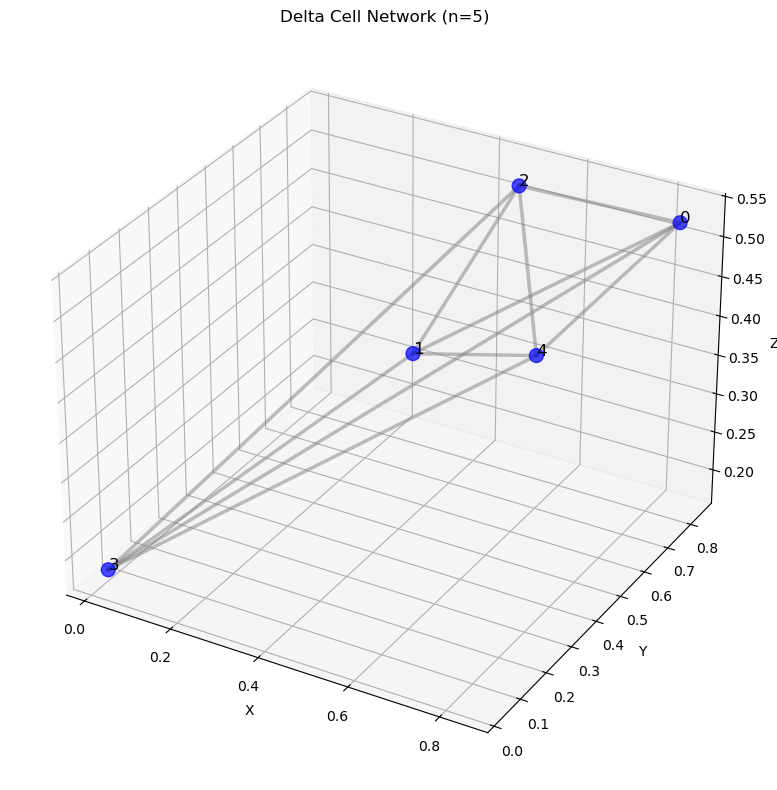

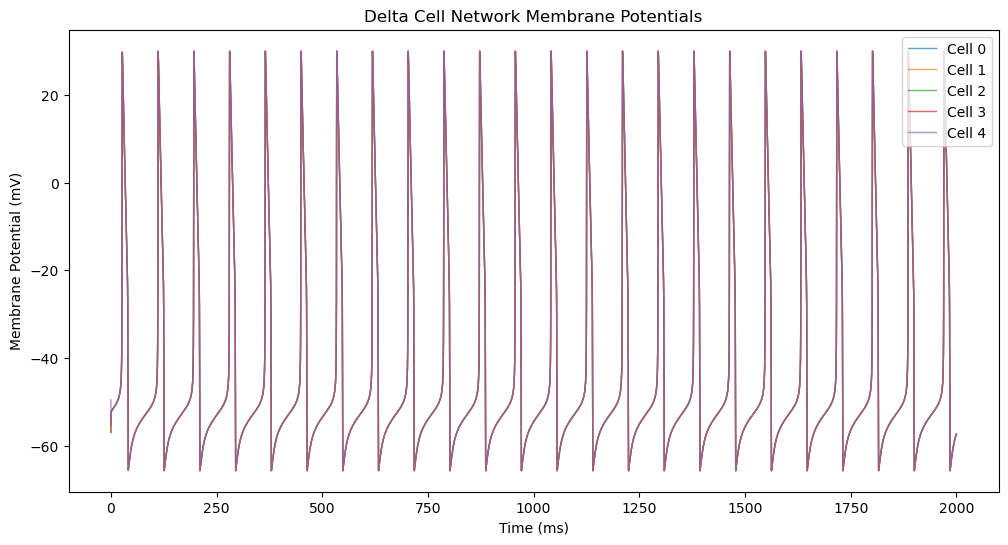

In [10]:
# Example usage
def main():
    # Create a delta cell network
    network = DeltaCellNetwork(num_cells=5, coupling_strength=1)

    # Simulate the network w/ no coupline
    # network = DeltaCellNetwork(num_cells=5, coupling_strength=0)

    # Visualize the network
    network.plot_network()

    # Simulate
    sol = network.simulate(tmax=2000)

    # Plot results
    network.plot_results(sol, figure_size=(12, 6))


# Uncomment to run the example
main()

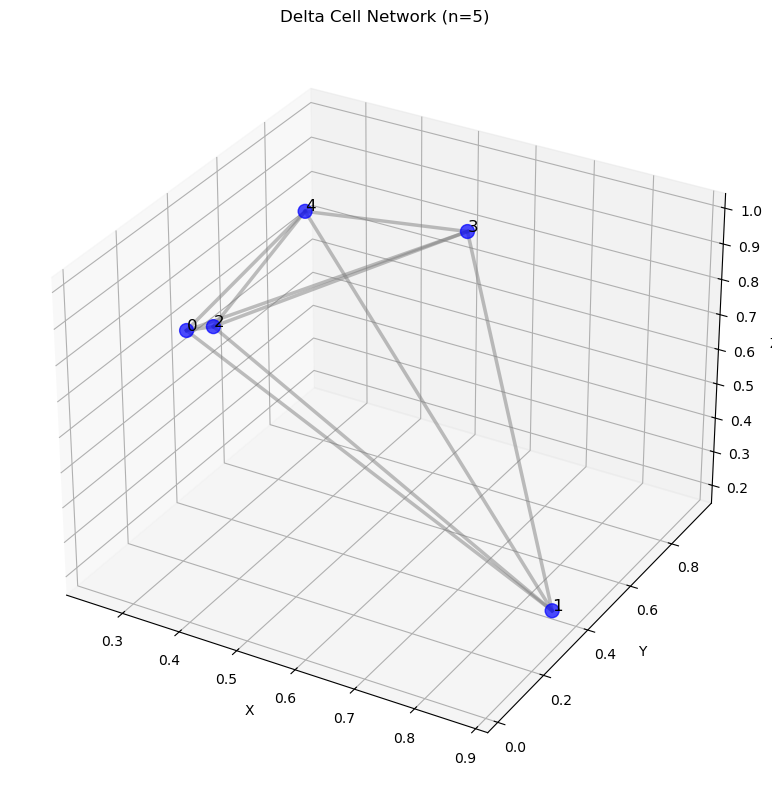

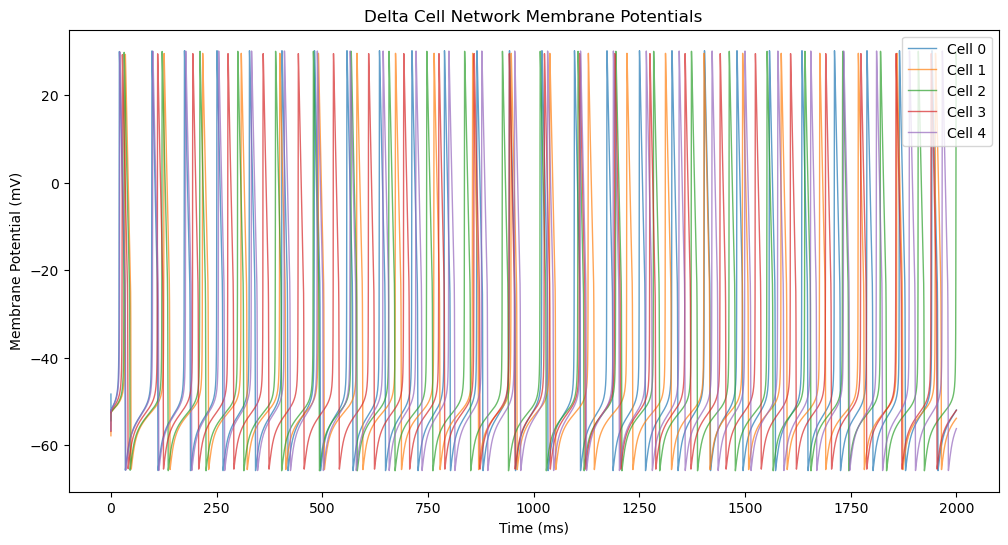

In [11]:
# Example usage
def main():
    # Create a delta cell network
    # network = DeltaCellNetwork(num_cells=5, coupling_strength=1)

    # Simulate the network w/ no coupline
    network = DeltaCellNetwork(num_cells=5, coupling_strength=0)

    # Visualize the network
    network.plot_network()

    # Simulate
    sol = network.simulate(tmax=2000)

    # Plot results
    network.plot_results(sol, figure_size=(12, 6))


# Uncomment to run the example
main()

# Coupling $\beta$ & $\delta$ cells together

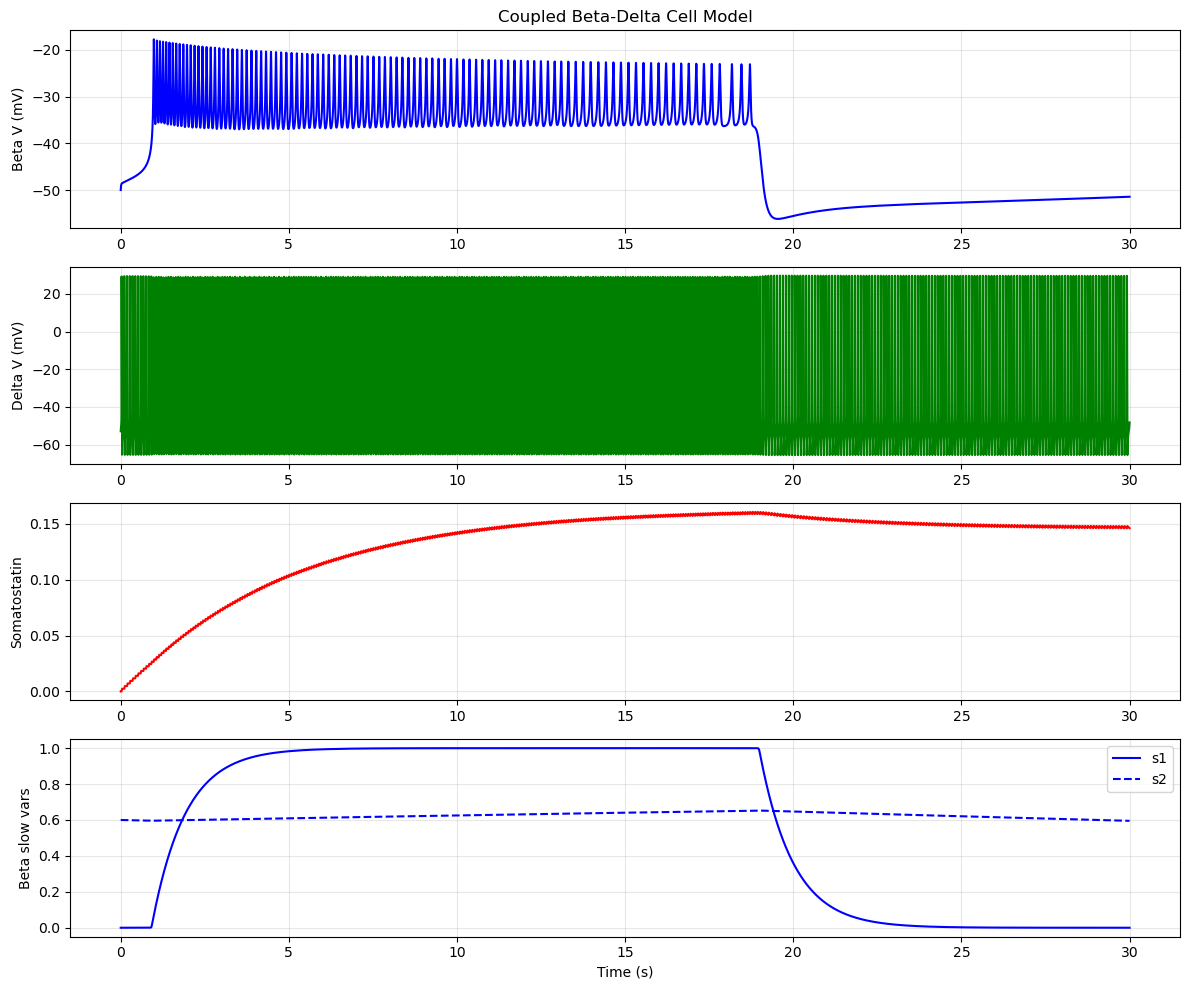

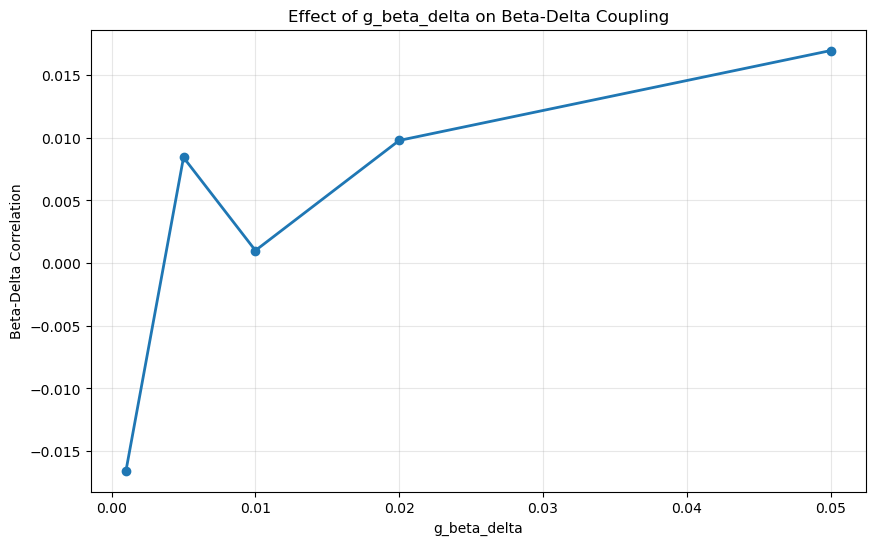

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


# Include the original cell models
class SingleBetaCell:
    def __init__(
        self,
        gs1=5,
        gs2=32,
        taus1=1000,
        taus2=120000,
        tnbar=9.09,
        vs1=-40,
        vs2=-42,
        ss1=0.5,
        ss2=0.4,
        s1knot=1,
        s2knot=1,
        gl=25,
        vl=-40,
        gk=1300,
        vk=-80,
        gca=280,
        vca=100,
        lambda_=1.1,
        cm=4524,
        vm=-22,
        sm=7.5,
        vn=-9,
        sn=10,
    ):
        # Store all parameters as instance variables
        self.gs1 = gs1
        self.gs2 = gs2
        self.taus1 = taus1
        self.taus2 = taus2
        self.tnbar = tnbar
        self.vs1 = vs1
        self.vs2 = vs2
        self.ss1 = ss1
        self.ss2 = ss2
        self.s1knot = s1knot
        self.s2knot = s2knot
        self.gl = gl
        self.vl = vl
        self.gk = gk
        self.vk = vk
        self.gca = gca
        self.vca = vca
        self.lambda_ = lambda_
        self.cm = cm
        self.vm = vm
        self.sm = sm
        self.vn = vn
        self.sn = sn

    def dynamics(self, t, x, v_neighbors=0, g_total=0):
        """Calculate the dynamics of the beta cell model"""
        # Unpack variables
        v, n, s1, s2 = x

        # Gating variables
        minf = 1.0 / (1.0 + np.exp((self.vm - v) / self.sm))
        ninf = 1.0 / (1.0 + np.exp((self.vn - v) / self.sn))
        taun = self.tnbar / (1.0 + np.exp((v - self.vn) / self.sn))
        s1inf = 1.0 / (1.0 + np.exp((self.vs1 - v) / self.ss1))
        s2inf = 1.0 / (1.0 + np.exp((self.vs2 - v) / self.ss2))

        # Ionic currents
        ica = self.gca * minf * (v - self.vca)
        ik = self.gk * n * (v - self.vk)
        il = self.gl * (v - self.vl)
        is1 = self.gs1 * s1 * (v - self.vk)
        is2 = self.gs2 * s2 * (v - self.vk)

        igj = g_total * (v_neighbors - v) if g_total > 0 else 0

        # Differential equations
        vdot = -(ica + ik + il + is1 + is2 - igj) / self.cm
        ndot = self.lambda_ * (ninf - n) / taun
        s1dot = (s1inf - s1) / self.taus1
        s2dot = (s2inf - s2) / self.taus2

        return np.array([vdot, ndot, s1dot, s2dot])


class SingleDeltaCell:
    def __init__(self, **kwargs):
        """
        Initialize a single delta cell model based on Briant et al.

        Parameters:
        -----------
        **kwargs: Parameter overrides for the delta cell model
        """
        # Default parameters
        self.params = {
            "gkatp": 0.01,
            "gna": 11,
            "gka": 1.2,
            "gkdr": 4.5,
            "vna": 60,
            "vk": -75,
            "vca": 65,
            "vl": -40,
            "cm": 4e-3,
            "gcal": 0.65,
            "gcat": 0.05,
            "gcan": 0.3,
            "gl": 0.1,
            "vcalm": -30,
            "scalm": 10,
            "vcalh": -33,
            "scalh": -5,
            "tcalh1": 60,
            "tcalh2": 51,
            "vcatm": -49,
            "scatm": 4,
            "vcath": -52,
            "scath": -5,
            "tcatm1": 15,
            "tcatm2": 0,
            "tcath1": 20,
            "tcath2": 5,
            "vcanm": -5,
            "scanm": 10,
            "vcanh": -33,
            "scanh": -5,
            "tcanh1": 2,
            "tcanh2": 2,
            "vnam": -30,
            "vnah": -52,
            "snam": 4,
            "snah": -8,
            "tnah1": 120,
            "tnah2": 0.5,
            "vkam": -45,
            "skam": 10,
            "vkah": -68,
            "skah": -10,
            "taukam": 0.1,
            "tkah1": 60,
            "tkah2": 5,
            "taukm": 1,
            "vkdrm": -25,
            "skdrm": 23,
            "V2m": -28.8749674,
            "sm": -5.45289598,
            "V2h": -45.388663,
            "sh": 4.99005762,
            "a1taum": 0.0001072,
            "b1taum": 12,
            "c1taum": 40,
            "a2taum": 0.000152,
            "b2taum": -20,
            "c2taum": 22.69,
            "a1tauh": 0.0001636,
            "b1tauh": -15,
            "c1tauh": 8.6856,
            "a2tauh": 0.0001857,
            "b2tauh": 5,
            "c2tauh": 35.35,
        }

        # Update parameters with any provided values
        self.params.update(kwargs)

        # Default initial conditions
        self.init = {
            "v": -52.91,
            "mcal": 0.092,
            "hcal": 0.857,
            "mcat": 0.27,
            "hcat": 0.534,
            "mcan": 0.008,
            "hcan": 0.857,
            "mna": 0.003,
            "hna": 0.339,
            "mka": 0.312,
            "hka": 0.182,
            "mkdr": 0.237,
        }

    def dynamics(self, t, y, v_neighbors=None, g_total=0):
        """
        Calculate the dynamics of the delta cell model

        Parameters:
        -----------
        t : float
            Current time
        y : array-like
            State variables: [v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr]
        v_neighbors : float or None
            Average voltage of neighboring cells
        g_total : float
            Total gap junction conductance to neighbors

        Returns:
        --------
        dydt : array
            Derivatives of state variables
        """
        v, mcal, hcal, mcat, hcat, mcan, hcan, mna, hna, mka, hka, mkdr = y
        p = self.params

        # Steady states and time constants
        mcalinf = 1 / (1 + np.exp(-(v - p["vcalm"]) / p["scalm"]))
        hcalinf = 1 / (1 + np.exp(-(v - p["vcalh"]) / p["scalh"]))
        taucalm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucalh = (p["tcalh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcalh2"]

        mcatinf = 1 / (1 + np.exp(-(v - p["vcatm"]) / p["scatm"]))
        hcatinf = 1 / (1 + np.exp(-(v - p["vcath"]) / p["scath"]))
        taucatm = (p["tcatm1"] / (np.exp(-(v + 50) / 12) + np.exp((v + 50) / 12))) + p[
            "tcatm2"
        ]
        taucath = (p["tcath1"] / (np.exp(-(v + 50) / 15) + np.exp((v + 50) / 15))) + p[
            "tcath2"
        ]

        mcaninf = 1 / (1 + np.exp(-(v - p["vcanm"]) / p["scanm"]))
        hcaninf = 1 / (1 + np.exp(-(v - p["vcanh"]) / p["scanh"]))
        taucanm = (1 / (np.exp(-(v + 23) / 20) + np.exp((v + 23) / 20))) + 0.05
        taucanh = (p["tcanh1"] / (np.exp(-v / 20) + np.exp(v / 20))) + p["tcanh2"]

        mnainf = 1 / (1 + np.exp((v - p["V2m"]) / p["sm"]))
        hnainf = 1 / (1 + np.exp((v - p["V2h"]) / p["sh"]))
        taunam = 1e3 * (
            p["a1taum"] * np.exp(-(((v - p["b1taum"]) / p["c1taum"]) ** 2))
            + p["a2taum"] * np.exp(-(((v - p["b2taum"]) / p["c2taum"]) ** 2))
        )
        taunah = 1e3 * (
            p["a1tauh"] * np.exp(-(((v - p["b1tauh"]) / p["c1tauh"]) ** 2))
            + p["a2tauh"] * np.exp(-(((v - p["b2tauh"]) / p["c2tauh"]) ** 2))
        )

        mkainf = 1 / (1 + np.exp(-(v - p["vkam"]) / p["skam"]))
        hkainf = 1 / (1 + np.exp(-(v - p["vkah"]) / p["skah"]))
        taukah = (p["tkah1"] / (np.exp(-(v - 5) / 20) + np.exp((v - 5) / 20))) + p[
            "tkah2"
        ]

        mkdrinf = 1 / (1 + np.exp(-(v - p["vkdrm"]) / p["skdrm"]))
        taukdrm = p["taukm"] * (
            (1.5 / (np.exp(-(v + 10) / 25) + np.exp((v + 10) / 25))) + 15
        )

        # Ionic currents
        Ical = p["gcal"] * mcal**2 * hcal * (v - p["vca"])
        Icat = p["gcat"] * mcat**3 * hcat * (v - p["vca"])
        Ican = p["gcan"] * mcan * hcan * (v - p["vca"])
        Ina = p["gna"] * mna**5 * hna * (v - p["vna"])
        Ika = p["gka"] * mka * hka * (v - p["vk"])
        Ikdr = p["gkdr"] * mkdr**4 * (v - p["vk"])
        Ikatp = p["gkatp"] * (v - p["vk"])
        Il = p["gl"] * (v - p["vl"])

        # Gap junction current
        Igj = g_total * (v_neighbors - v) if v_neighbors is not None else 0

        # Differential equations
        dydt = np.zeros(12)
        dydt[0] = (
            -(Ical + Icat + Ican + Ina + Ikdr + Ikatp + Ika + Il - Igj) / p["cm"]
        )  # dv
        dydt[1] = (mcalinf - mcal) / (1 * taucalm)  # dmcal
        dydt[2] = (hcalinf - hcal) / (1 * taucalh)  # dhcal
        dydt[3] = (mcatinf - mcat) / (1 * taucatm)  # dmcat
        dydt[4] = (hcatinf - hcat) / (1 * taucath)  # dhcat
        dydt[5] = (mcaninf - mcan) / (1 * taucanm)  # dmcan
        dydt[6] = (hcaninf - hcan) / (1 * taucanh)  # dhcan
        dydt[7] = (mnainf - mna) / taunam  # dmna
        dydt[8] = (hnainf - hna) / taunah  # dhna
        dydt[9] = (mkainf - mka) / p["taukam"]  # dmka
        dydt[10] = (hkainf - hka) / taukah  # dhka
        dydt[11] = (mkdrinf - mkdr) / taukdrm  # dmkdr

        return dydt


class CoupledBetaDeltaModel:
    def __init__(self, beta_params=None, delta_params=None, **kwargs):
        """
        Initialize a coupled beta-delta cell model

        Parameters:
        -----------
        beta_params : dict, optional
            Parameters for the beta cell model
        delta_params : dict, optional
            Parameters for the delta cell model
        **kwargs : dict
            Coupling parameters
        """
        # Default coupling parameters
        self.coupling_params = {
            "g_beta_delta": 0.01,  # Gap junction conductance from beta to delta
            "g_delta_beta": 0.01,  # Gap junction conductance from delta to beta
            "somatostatin_strength": 0.2,  # Effect of somatostatin on beta cell
            "somatostatin_threshold": -35,  # Voltage threshold for somatostatin release
            "somatostatin_tau": 5000,  # Time constant for somatostatin effect (ms)
        }

        # Update with any provided values
        self.coupling_params.update(kwargs)

        # Initialize the individual cell models
        self.beta_cell = SingleBetaCell(**(beta_params or {}))
        self.delta_cell = SingleDeltaCell(**(delta_params or {}))

        # Initial conditions
        self.beta_init = np.array([-50, 0.0, 0.0, 0.6])  # v, n, s1, s2
        self.delta_init = np.array(
            [
                self.delta_cell.init["v"],
                self.delta_cell.init["mcal"],
                self.delta_cell.init["hcal"],
                self.delta_cell.init["mcat"],
                self.delta_cell.init["hcat"],
                self.delta_cell.init["mcan"],
                self.delta_cell.init["hcan"],
                self.delta_cell.init["mna"],
                self.delta_cell.init["hna"],
                self.delta_cell.init["mka"],
                self.delta_cell.init["hka"],
                self.delta_cell.init["mkdr"],
            ]
        )

        # Add somatostatin as a state variable
        self.somatostatin = 0.0

    def dynamics(self, t, y):
        """
        Calculate the dynamics of the coupled beta-delta cell model

        Parameters:
        -----------
        t : float
            Current time
        y : array-like
            State variables: [beta_v, beta_n, beta_s1, beta_s2, delta_v, ...]

        Returns:
        --------
        dydt : array
            Derivatives of state variables
        """
        # Split state variables
        beta_vars = y[:4]
        delta_vars = y[4:16]
        somatostatin = y[16]

        # Extract voltages
        beta_v = beta_vars[0]
        delta_v = delta_vars[0]

        # Calculate somatostatin release based on delta cell activity
        somatostatin_release = 0
        if delta_v > self.coupling_params["somatostatin_threshold"]:
            somatostatin_release = (
                delta_v - self.coupling_params["somatostatin_threshold"]
            ) / 30.0
            somatostatin_release = min(max(somatostatin_release, 0), 1)

        # Somatostatin dynamics
        dsomatostatin = (somatostatin_release - somatostatin) / self.coupling_params[
            "somatostatin_tau"
        ]

        # Calculate beta cell dynamics with influence from delta cell
        # Modify beta cell parameters based on somatostatin level
        # Somatostatin reduces calcium currents in beta cells
        original_gca = self.beta_cell.gca
        self.beta_cell.gca = original_gca * (
            1 - self.coupling_params["somatostatin_strength"] * somatostatin
        )

        beta_dydt = self.beta_cell.dynamics(
            t,
            beta_vars,
            v_neighbors=delta_v,
            g_total=self.coupling_params["g_delta_beta"],
        )

        # Restore original parameters
        self.beta_cell.gca = original_gca

        # Calculate delta cell dynamics with influence from beta cell
        delta_dydt = self.delta_cell.dynamics(
            t,
            delta_vars,
            v_neighbors=beta_v,
            g_total=self.coupling_params["g_beta_delta"],
        )

        # Combine all derivatives
        dydt = np.concatenate([beta_dydt, delta_dydt, [dsomatostatin]])

        return dydt

    def simulate(self, tmax=30000, max_step=5.0):
        """
        Simulate the coupled beta-delta cell model

        Parameters:
        -----------
        tmax : float
            Maximum simulation time in ms
        max_step : float
            Maximum step size for the solver

        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """
        # Initial conditions vector
        y0 = np.concatenate(
            [self.beta_init, self.delta_init, [0.0]]
        )  # Add somatostatin

        tspan = (0, tmax)

        # Solve ODE
        sol = solve_ivp(
            self.dynamics,
            tspan,
            y0,
            method="LSODA",
            max_step=max_step,
            rtol=1e-6,
            atol=1e-6,
        )

        return sol

    def plot_results(self, sol, figure_size=(12, 10)):
        """
        Plot the simulation results

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method
        """
        tsec = sol.t / 1000  # convert ms to seconds

        # Extract results
        beta_v = sol.y[0]
        beta_s1 = sol.y[2]
        beta_s2 = sol.y[3]
        delta_v = sol.y[4]
        somatostatin = sol.y[16]

        plt.figure(figsize=figure_size)

        # Beta cell voltage
        plt.subplot(4, 1, 1)
        plt.plot(tsec, beta_v, "b-", linewidth=1.5)
        plt.ylabel("Beta V (mV)")
        plt.title("Coupled Beta-Delta Cell Model")
        plt.grid(True, alpha=0.3)

        # Delta cell voltage
        plt.subplot(4, 1, 2)
        plt.plot(tsec, delta_v, "g-", linewidth=1.5)
        plt.ylabel("Delta V (mV)")
        plt.grid(True, alpha=0.3)

        # Somatostatin level
        plt.subplot(4, 1, 3)
        plt.plot(tsec, somatostatin, "r-", linewidth=1.5)
        plt.ylabel("Somatostatin")
        plt.grid(True, alpha=0.3)

        # Beta cell slow variables
        plt.subplot(4, 1, 4)
        plt.plot(tsec, beta_s1, "b-", linewidth=1.5, label="s1")
        plt.plot(tsec, beta_s2, "b--", linewidth=1.5, label="s2")
        plt.ylabel("Beta slow vars")
        plt.xlabel("Time (s)")
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def analyze_synchronization(self, sol):
        """
        Analyze the synchronization between beta and delta cells

        Parameters:
        -----------
        sol : OdeSolution
            Solution from simulate method

        Returns:
        --------
        results : dict
            Dictionary with synchronization metrics
        """
        # Extract voltages
        beta_v = sol.y[0]
        delta_v = sol.y[4]

        # Compute correlation
        correlation = np.corrcoef(beta_v, delta_v)[0, 1]

        # Detect peaks (crude spike detection)
        beta_peaks = []
        delta_peaks = []

        for i in range(1, len(sol.t) - 1):
            # Beta cell peaks
            if (
                beta_v[i] > beta_v[i - 1]
                and beta_v[i] > beta_v[i + 1]
                and beta_v[i] > -30
            ):
                beta_peaks.append(sol.t[i])

            # Delta cell peaks
            if (
                delta_v[i] > delta_v[i - 1]
                and delta_v[i] > delta_v[i + 1]
                and delta_v[i] > -30
            ):
                delta_peaks.append(sol.t[i])

        # Compute phase difference if both cells are spiking
        phase_diffs = []
        if len(beta_peaks) > 0 and len(delta_peaks) > 0:
            # Compute average period for beta cell
            beta_periods = np.diff(beta_peaks)
            if len(beta_periods) > 0:
                avg_beta_period = np.mean(beta_periods)

                # For each beta peak, find closest delta peak
                for bp in beta_peaks:
                    if len(delta_peaks) > 0:
                        closest_dp = min(delta_peaks, key=lambda x: abs(x - bp))
                        phase_diff = ((closest_dp - bp) / avg_beta_period) % 1.0
                        phase_diffs.append(phase_diff)

        return {
            "correlation": correlation,
            "beta_peaks": len(beta_peaks),
            "delta_peaks": len(delta_peaks),
            "phase_differences": phase_diffs,
            "mean_phase_diff": np.mean(phase_diffs) if len(phase_diffs) > 0 else None,
        }

    def parameter_scan(self, param_name, values, tmax=10000):
        """
        Perform a parameter scan

        Parameters:
        -----------
        param_name : str
            Name of parameter to scan
        values : list
            List of parameter values to scan
        tmax : float
            Maximum simulation time for each run

        Returns:
        --------
        results : dict
            Dictionary with results for each parameter value
        """
        results = {}

        for val in values:
            # Set parameter
            if param_name in self.coupling_params:
                self.coupling_params[param_name] = val
            elif hasattr(self.beta_cell, param_name):
                setattr(self.beta_cell, param_name, val)
            elif hasattr(self.delta_cell.params, param_name):
                self.delta_cell.params[param_name] = val
            else:
                raise ValueError(f"Unknown parameter: {param_name}")

            # Run simulation
            sol = self.simulate(tmax=tmax)

            # Analyze results
            sync_results = self.analyze_synchronization(sol)
            results[val] = {"sol": sol, "sync": sync_results}

        return results

    def plot_parameter_scan(self, results, param_name):
        """
        Plot results of parameter scan

        Parameters:
        -----------
        results : dict
            Results from parameter_scan method
        param_name : str
            Name of parameter that was scanned
        """
        values = sorted(results.keys())
        correlations = [results[v]["sync"]["correlation"] for v in values]

        plt.figure(figsize=(10, 6))
        plt.plot(values, correlations, "o-", linewidth=2)
        plt.xlabel(param_name)
        plt.ylabel("Beta-Delta Correlation")
        plt.grid(True, alpha=0.3)
        plt.title(f"Effect of {param_name} on Beta-Delta Coupling")
        plt.show()


# Example usage
def main():
    # Create instance with default parameters
    model = CoupledBetaDeltaModel(
        g_beta_delta=0.005, g_delta_beta=0.005, somatostatin_strength=0.3
    )

    # Run simulation
    sol = model.simulate(tmax=30000)

    # Plot results
    model.plot_results(sol)

    # Parameter scan example
    g_values = [0.001, 0.005, 0.01, 0.02, 0.05]
    results = model.parameter_scan("g_beta_delta", g_values, tmax=10000)
    model.plot_parameter_scan(results, "g_beta_delta")


if __name__ == "__main__":
    main()

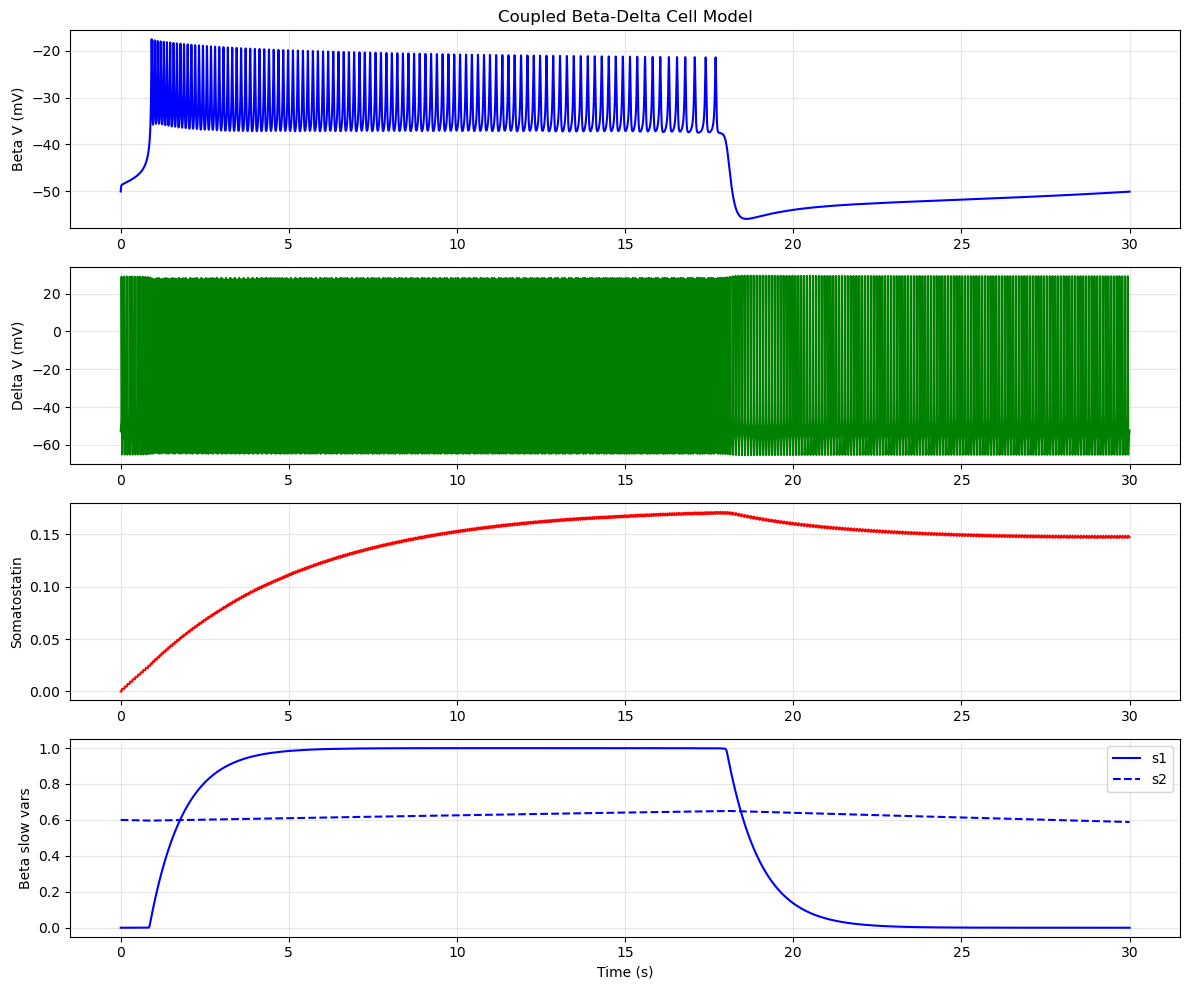

In [15]:
# Create the coupled model with custom parameters
model = CoupledBetaDeltaModel(
    g_beta_delta=0.01, g_delta_beta=0.01, somatostatin_strength=0.2
)

# Run a simulation
sol = model.simulate(tmax=30000)

# Plot results
model.plot_results(sol)

# Analyze synchronization
sync_data = model.analyze_synchronization(sol)